# MTSD 数据集探索

## 目的
分析 MTSD 数据集的特点，包括：
- 类别分布
- 图片和标注的对应关系
- 可视化特定类别的样本

## 数据路径
- 数据集根目录：`/Users/weixianfu/Documents/Datas/mtsd`
- 训练集：`train_full/images` 和 `train_full/labels`
- 验证集：`val/images` 和 `val/labels`
- 类别文件：`classes.json`


In [22]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


In [23]:
# Configure data paths
DATA_ROOT = Path("/Users/weixianfu/Documents/Datas/mtsd")
CLASSES_FILE = DATA_ROOT / "classes.json"

# Select dataset split to analyze (train_full, train_partial, val, sample)
DATASET_SPLIT = "train_full"  # Options: "val", "train_partial", "sample"

IMAGES_DIR = DATA_ROOT / DATASET_SPLIT / "images"
LABELS_DIR = DATA_ROOT / DATASET_SPLIT / "labels"


In [24]:
# Load class information
with open(CLASSES_FILE, 'r', encoding='utf-8') as f:
    classes_data = json.load(f)
    
class_names = classes_data.get('names', [])
print(f"Total classes: {len(class_names)}")
print(f"First 10 classes: {class_names[:10]}")


Total classes: 401
First 10 classes: ['warning--traffic-merges-right--g1', 'warning--added-lane-right--g1', 'warning--playground--g1', 'other-sign', 'regulatory--no-stopping--g15', 'regulatory--priority-road--g4', 'warning--pedestrian-stumble-train--g1', 'regulatory--maximum-speed-limit-45--g3', 'regulatory--stop--g1', 'warning--railroad-crossing--g1']


In [25]:
# Get all image files
image_files = list(IMAGES_DIR.glob("*.jpg")) 
print(f"Total images: {len(image_files)}")

Total images: 36589


In [26]:
# Filter images containing a specific class
def find_images_with_class(target_class_id: int) -> list:
    """
    Find all images containing the specified class
    
    Parameters:
    -----------
    target_class_id : int
        Target class ID
        
    Returns:
    -------
    list[Path]
        List of image paths containing this class
    """
    matching_images = []
    
    for image_file in image_files:
        label_file = LABELS_DIR / f"{image_file.stem}.txt"
        
        if not label_file.exists():
            continue
            
        # Read label file
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        # Check if contains target class
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) == target_class_id:
                matching_images.append(image_file)
                break
    
    return matching_images


In [27]:
# Select class to view (modify the class name here)
target_class_name = "regulatory--stop--g1"  # Change to the class you want to view

# Find class ID
try:
    target_class_id = class_names.index(target_class_name)
    print(f"Class '{target_class_name}' ID: {target_class_id}")
except ValueError:
    print(f"Class not found: {target_class_name}")
    print(f"Available class examples: {class_names[:5]}")
    target_class_id = 0  # Default to first class


Class 'regulatory--stop--g1' ID: 8


In [28]:
# Find all images containing this class
matching_images = find_images_with_class(target_class_id)
print(f"Images containing class '{class_names[target_class_id]}': {len(matching_images)}")

if len(matching_images) == 0:
    print("No images found with this class. Please check class ID or dataset path.")


Images containing class 'regulatory--stop--g1': 1010


In [29]:
# Randomly select an image
if matching_images:
    selected_image = random.choice(matching_images)
    print(f"Selected image: {selected_image.name}")
    
    # Read image
    image = Image.open(selected_image)
    img_width, img_height = image.size
    print(f"Image size: {img_width} x {img_height}")
    
    # Read corresponding label file
    label_file = LABELS_DIR / f"{selected_image.stem}.txt"
    
    boxes = []
    class_ids = []
    box_sizes = []  # Store size of each box
    
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    # Convert to absolute coordinates (x1, y1, x2, y2)
                    x1 = (x_center - width / 2) * img_width
                    y1 = (y_center - height / 2) * img_height
                    x2 = (x_center + width / 2) * img_width
                    y2 = (y_center + height / 2) * img_height
                    
                    # Calculate box width and height (pixels)
                    box_width = x2 - x1
                    box_height = y2 - y1
                    
                    boxes.append((x1, y1, x2, y2))
                    class_ids.append(class_id)
                    box_sizes.append((box_width, box_height))
    
    print(f"\nDetected objects: {len(boxes)}")
    print(f"\nBox details:")
    for i, (class_id, (w, h)) in enumerate(zip(class_ids, box_sizes)):
        class_name = class_names[class_id]
        print(f"  Box {i+1}: {class_name} (ID: {class_id})")
        print(f"    Size: {w:.1f} x {h:.1f} pixels")
        print(f"    Coordinates: ({boxes[i][0]:.1f}, {boxes[i][1]:.1f}) -> ({boxes[i][2]:.1f}, {boxes[i][3]:.1f})")
        print()


Selected image: fully_train_hXxVCGJkYg-yucAuDJf7og.jpg
Image size: 4032 x 3024

Detected objects: 3

Box details:
  Box 1: regulatory--stop--g1 (ID: 8)
    Size: 21.7 x 22.1 pixels
    Coordinates: (1844.7, 1378.4) -> (1866.4, 1400.5)

  Box 2: information--pedestrians-crossing--g1 (ID: 25)
    Size: 85.6 x 83.4 pixels
    Coordinates: (2849.8, 1215.2) -> (2935.4, 1298.6)

  Box 3: information--pedestrians-crossing--g1 (ID: 25)
    Size: 77.8 x 77.5 pixels
    Coordinates: (1794.5, 1243.3) -> (1872.3, 1320.8)



Saved original image to: original_image.png


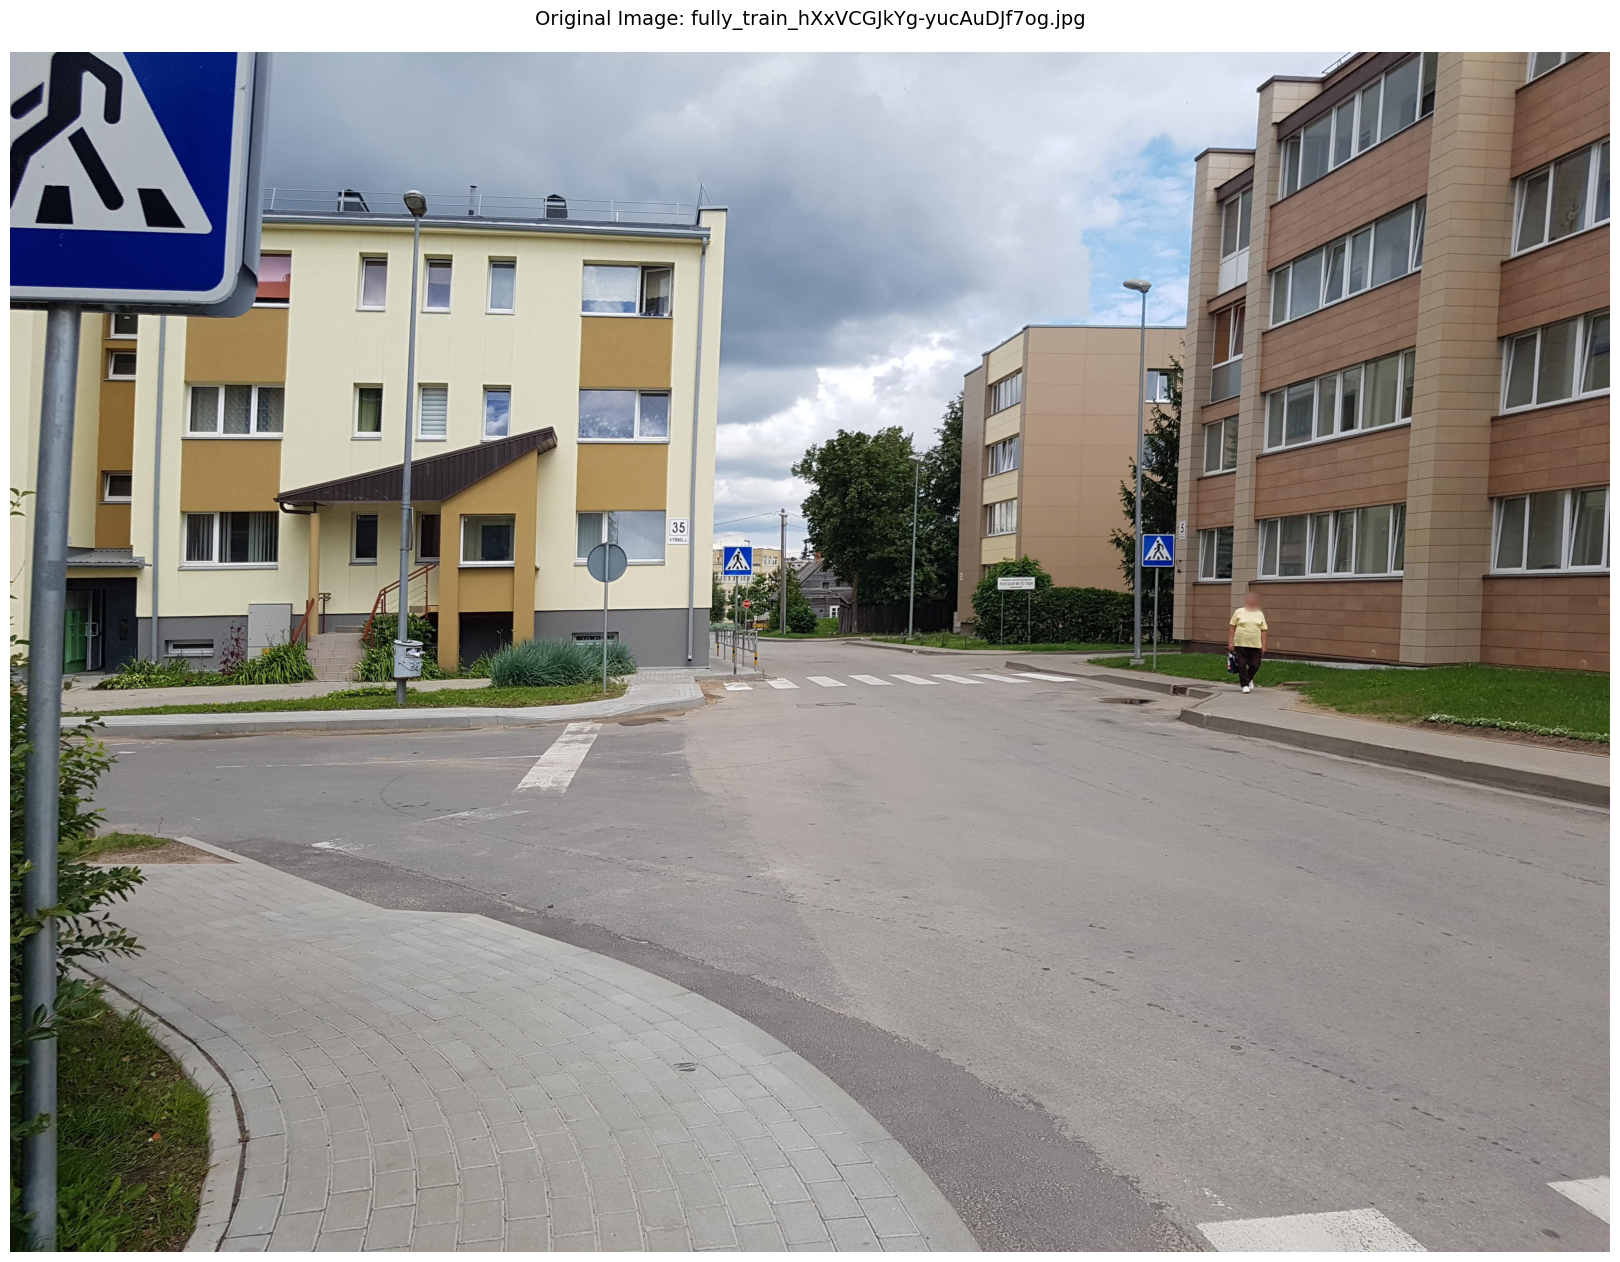

Saved annotated image to: annotated_image.png


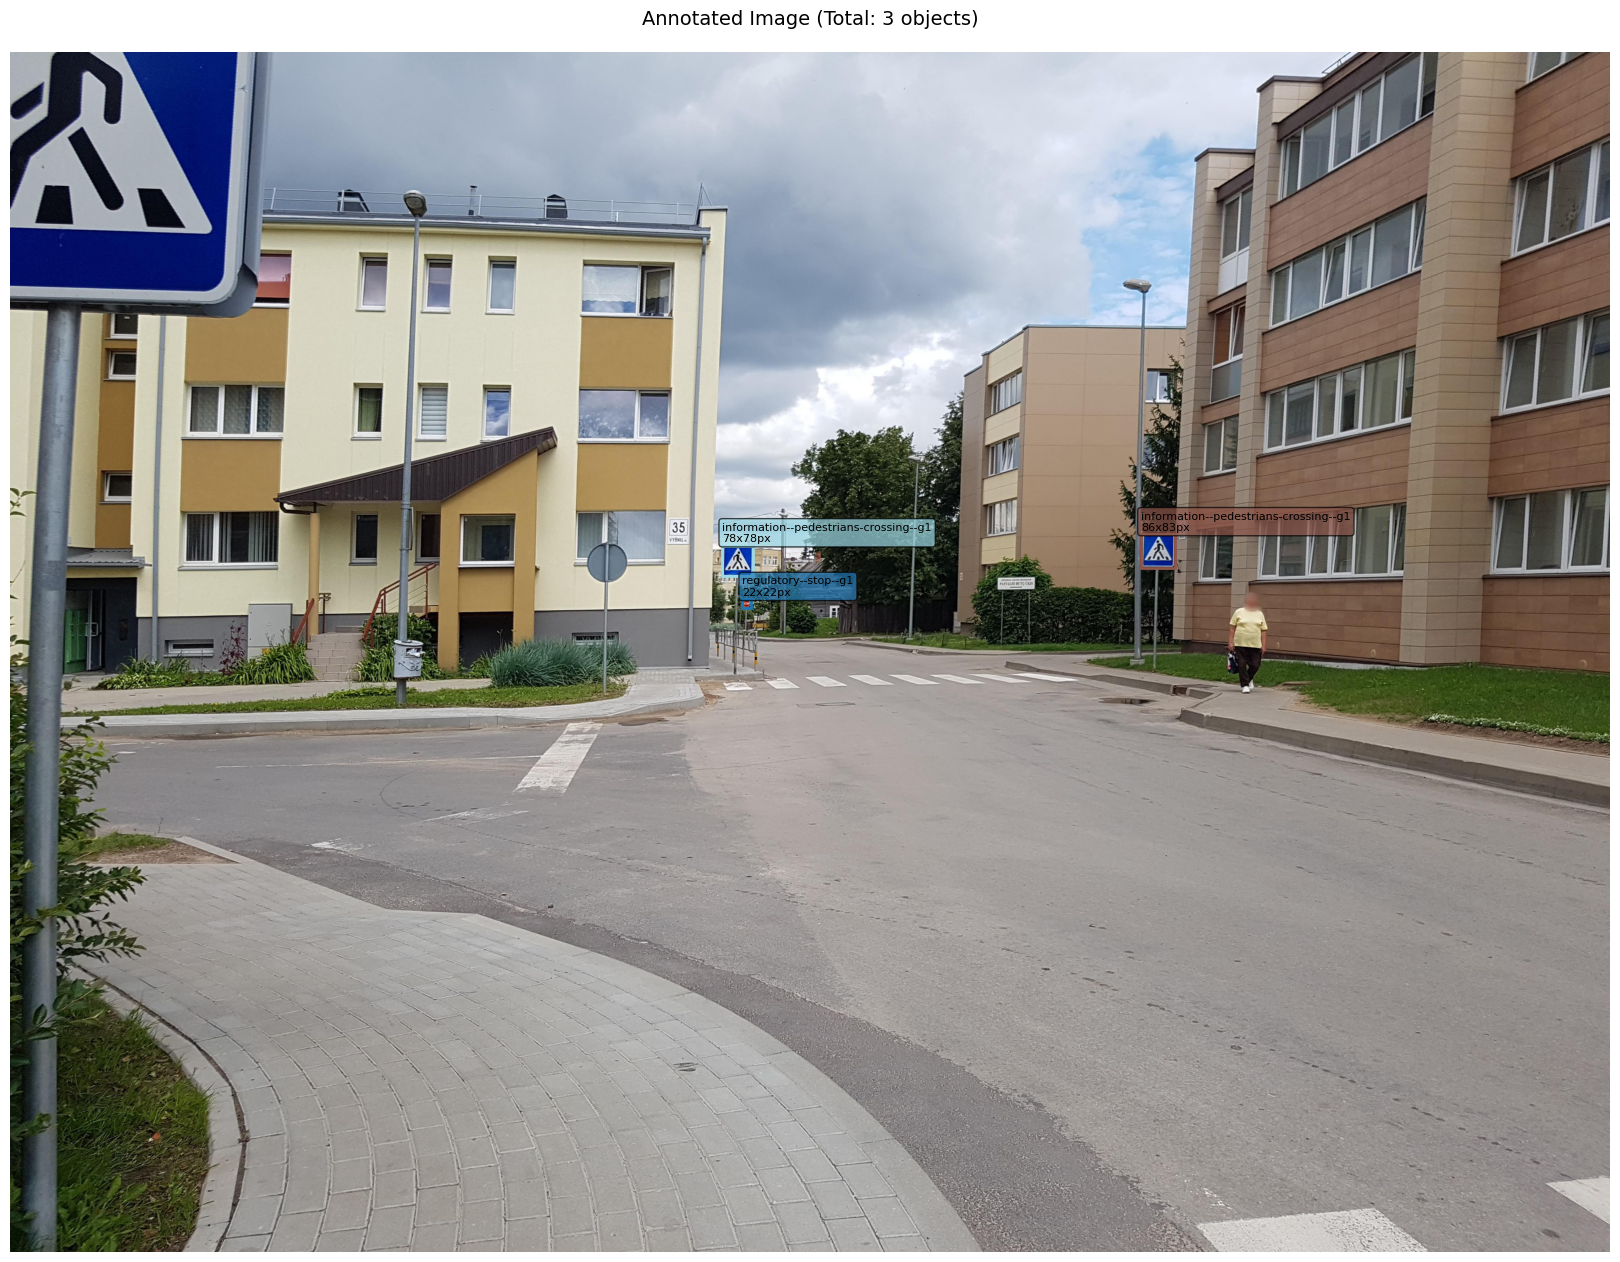

In [42]:
# Display and save original and annotated images
if matching_images:
    dpi = 100
    max_display_width = 16
    max_display_height = 12
    
    fig_width = img_width / dpi
    fig_height = img_height / dpi
    
    if fig_width > max_display_width:
        scale = max_display_width / fig_width
        fig_width = max_display_width
        fig_height = fig_height * scale
    if fig_height > max_display_height:
        scale = max_display_height / fig_height
        fig_height = max_display_height
        fig_width = fig_width * scale
    
    # Original image
    fig1 = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax1 = fig1.add_axes([0, 0, 1, 1])
    ax1.imshow(image)
    ax1.set_title(f"Original Image: {selected_image.name}", fontsize=14, pad=20)
    ax1.axis('off')
    
    original_path = Path("original_image.png")
    fig1.savefig(original_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
    print(f"Saved original image to: {original_path}")
    plt.show()
    
    # Annotated image
    fig2 = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax2 = fig2.add_axes([0, 0, 1, 1])
    ax2.imshow(image)
    ax2.set_title(f"Annotated Image (Total: {len(boxes)} objects)", fontsize=14, pad=20)
    ax2.axis('off')
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(boxes)))
    for i, ((x1, y1, x2, y2), class_id, (w, h)) in enumerate(zip(boxes, class_ids, box_sizes)):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=colors[i], facecolor='none')
        ax2.add_patch(rect)
        class_name = class_names[class_id]
        label_text = f"{class_name}\n{w:.0f}x{h:.0f}px"
        ax2.text(x1, y1 - 5, label_text, bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7), fontsize=8, color='black', verticalalignment='bottom')
    
    annotated_path = Path("annotated_image.png")
    fig2.savefig(annotated_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
    print(f"Saved annotated image to: {annotated_path}")
    plt.show()


In [41]:
# Delete saved images
Path("original_image.png").unlink()
Path("annotated_image.png").unlink()